[*] As imagens serão salvas em: /home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/reports/figures/analise_003
✅ Períodos que chegaram no gráfico: ['2019.1', '2019.2', '2020.1', '2020.2', '2021.1', '2021.2']
  -> Gráfico Nacional salvo com sucesso em: funil_nacional_por_area_cine.png


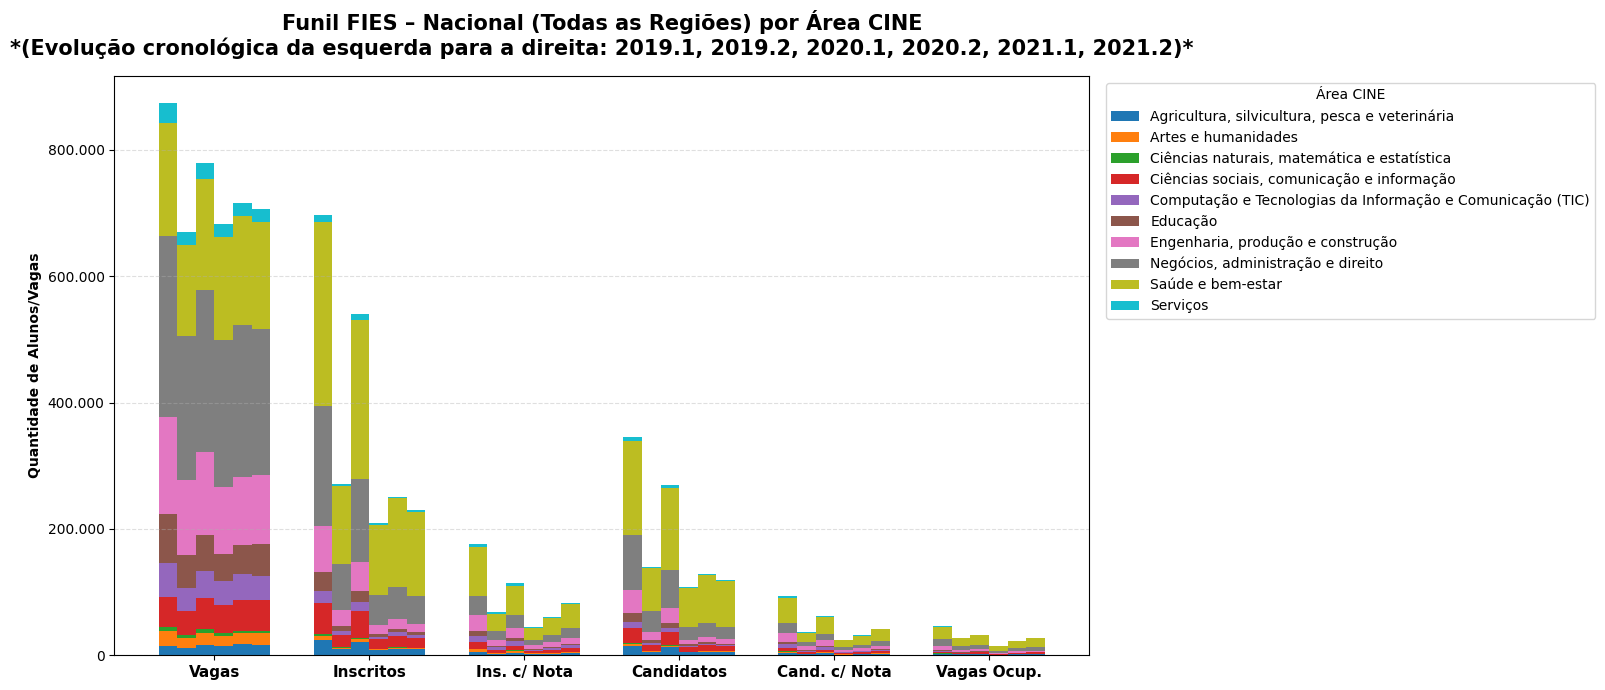

In [ ]:
# trata-se da utilizacao do funil_por_regiao.parquet para criacao de graficos e insights

import pandas as pd
from constantes import pasta_data_05_processed
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from pathlib import Path

# ==============================================================================
# 0. CONFIGURAÇÃO DE DIRETÓRIOS PARA SALVAR IMAGENS
# ==============================================================================
pasta_destino_graficos = Path('../reports/figures/analise_003').resolve()
pasta_destino_graficos.mkdir(parents=True, exist_ok=True)
print(f"[*] As imagens serão salvas em: {pasta_destino_graficos}")

# --- 1. Ler arquivo ---
path_funil_regiao = pasta_data_05_processed / 'funil_por_regiao.parquet'
df = pd.read_parquet(str(path_funil_regiao))

# --- 2. Criar coluna de período (ano + semestre) ---
# A transformação limpa de Inteiros para String
df['periodo'] = df['ano'].astype(str) + '.' + df['semestre'].astype(str)

# --- AUDITORIA RÁPIDA PARA VOCÊ VER NO TERMINAL ---
periodos_encontrados = sorted(df['periodo'].unique())
print(f"✅ Períodos que chegaram no gráfico: {periodos_encontrados}")

# --- 3. Definir colunas e nomes curtos ---
colunas_funil = [
    'vagas_fies',
    'Inscritos_Geral',
    'inscritos_com_nota_suficiente',
    'Candidatos_Unicos_Geral',
    'candidatos_unicos_com_nota_suficiente',
    'vagas_ocupadas'
]

nomes_curto = {
    'vagas_fies': 'Vagas',
    'Inscritos_Geral': 'Inscritos',
    'inscritos_com_nota_suficiente': 'Ins. c/ Nota',
    'Candidatos_Unicos_Geral': 'Candidatos',
    'candidatos_unicos_com_nota_suficiente': 'Cand. c/ Nota',
    'vagas_ocupadas': 'Vagas Ocup.'
}

# --- 4. Agregar dados a nível nacional (somando todas as regiões) ---
# A MÁGICA AQUI: Se for NaN, vira 'Não Informado' e o Pandas para de deletar a linha!
df['nome_cine_area_geral'] = df['nome_cine_area_geral'].fillna('CINE Não Informado (MEC)')

df_nacional = (
    df.groupby(['periodo', 'nome_cine_area_geral'], dropna=False)[colunas_funil]
    .sum()
    .reset_index()
)

# --- 5. Parâmetros básicos ---
areas = sorted(df_nacional['nome_cine_area_geral'].unique())
periodos = sorted(df_nacional['periodo'].unique())
largura_barra = 0.12
cores_areas = plt.cm.tab10(np.linspace(0, 1, len(areas)))

# --- 6. Criar gráfico nacional ---
fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(colunas_funil))
deslocamentos = np.linspace(-largura_barra * 2.5, largura_barra * 2.5, len(periodos))

for desloc, periodo in zip(deslocamentos, periodos):
    df_periodo = df_nacional[df_nacional['periodo'] == periodo]
    base = np.zeros(len(colunas_funil))

    for cor, area in zip(cores_areas, areas):
        valores = df_periodo[df_periodo['nome_cine_area_geral'] == area][colunas_funil]
        if valores.empty:
            valores = [0] * len(colunas_funil)
        else:
            valores = valores.values[0]

        ax.bar(
            x + desloc,
            valores,
            width=largura_barra,
            bottom=base,
            color=cor,
            label=area if periodo == periodos[0] else ""
        )
        # Proteção com NumPy Array para não quebrar a soma das bases
        base += np.array(valores)

ax.set_xticks(x)
ax.set_xticklabels([nomes_curto[c] for c in colunas_funil], rotation=0, fontweight='bold', fontsize=11)
ax.set_ylabel('Quantidade de Alunos/Vagas', fontweight='bold')

# Formatador de eixo Y para não ter notação científica (ex: mostrar 1.500.000 em vez de 1.5e6)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val):,}'.replace(',', '.')))

# Adicionando um subtítulo claro para explicar a linha do tempo!
texto_timeline = f"*(Evolução cronológica da esquerda para a direita: {', '.join(periodos)})*"
ax.set_title(f'Funil FIES – Nacional (Todas as Regiões) por Área CINE\n{texto_timeline}', 
             fontsize=15, fontweight='bold', pad=15)

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(title='Área CINE', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1)

plt.tight_layout()

# ==============================================================================
# 7. EXPORTAR A IMAGEM (SEMPRE ANTES DO SHOW)
# ==============================================================================
nome_arquivo = "funil_nacional_por_area_cine.png"
caminho_salvar = pasta_destino_graficos / nome_arquivo
plt.savefig(caminho_salvar, dpi=300, bbox_inches='tight')
print(f"  -> Gráfico Nacional salvo com sucesso em: {nome_arquivo}")

plt.show()

[*] As imagens serão salvas em: /home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/reports/figures/analise_003

[*] Gerando e salvando gráficos por Área CINE...
  -> Salvo: funil_agricultura_silvicultura_pesca_e_veterinária.png


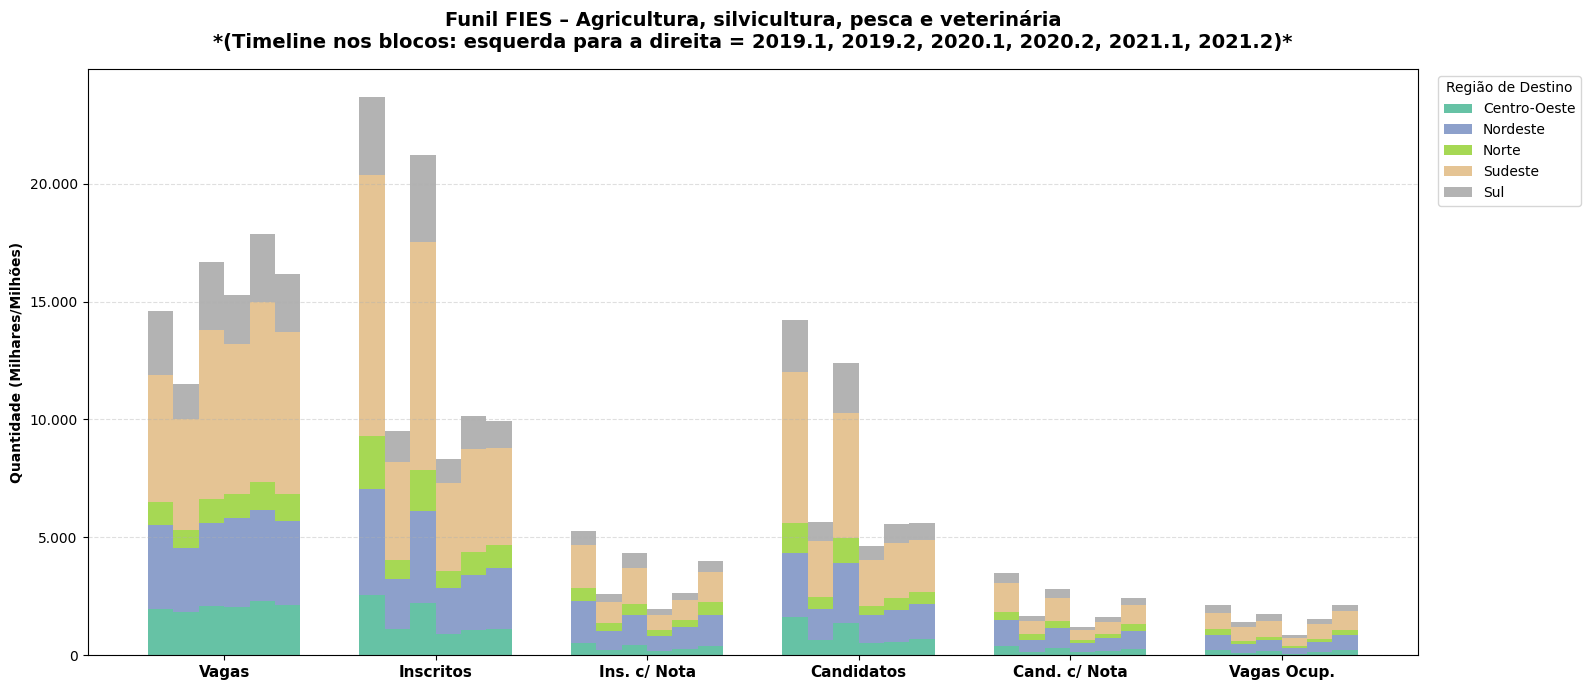

  -> Salvo: funil_artes_e_humanidades.png


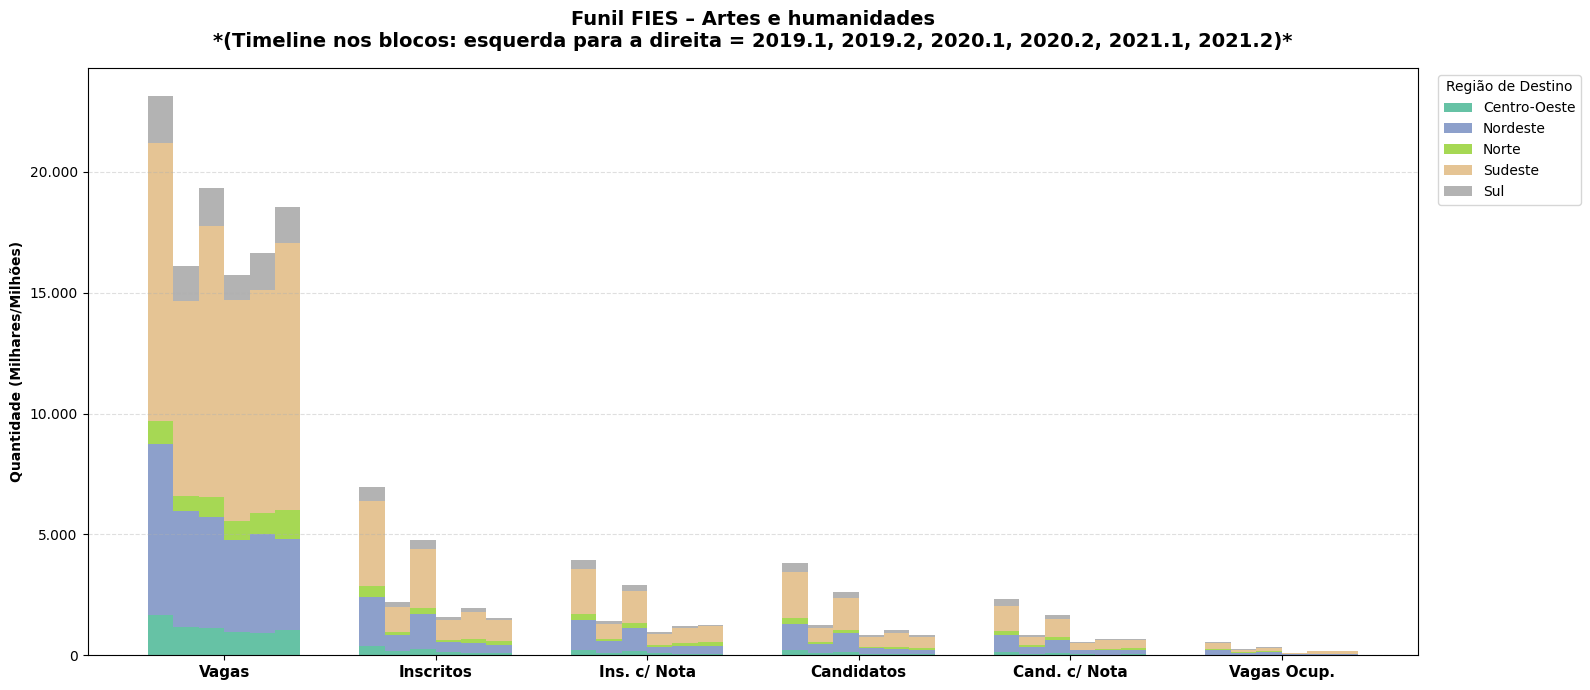

  -> Salvo: funil_ciências_naturais_matemática_e_estatística.png


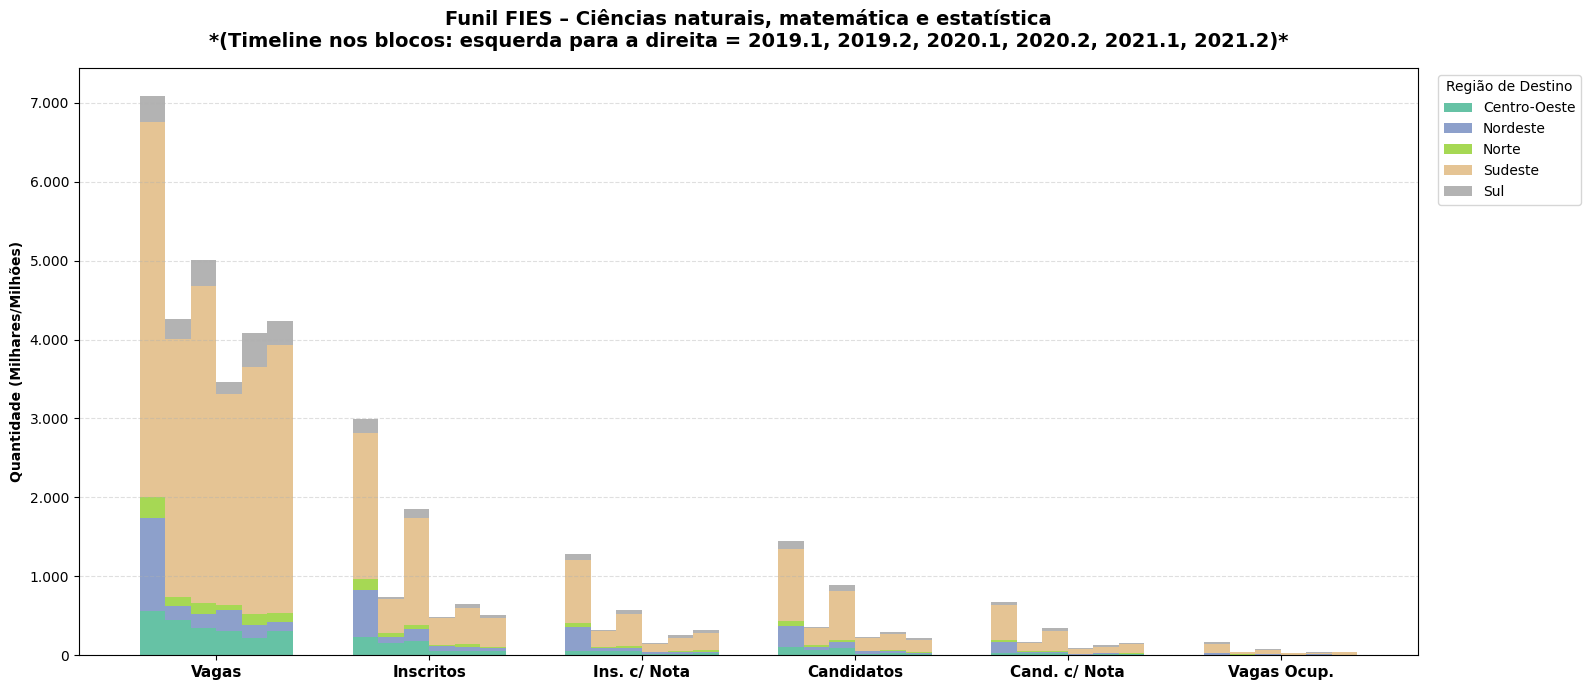

  -> Salvo: funil_ciências_sociais_comunicação_e_informação.png


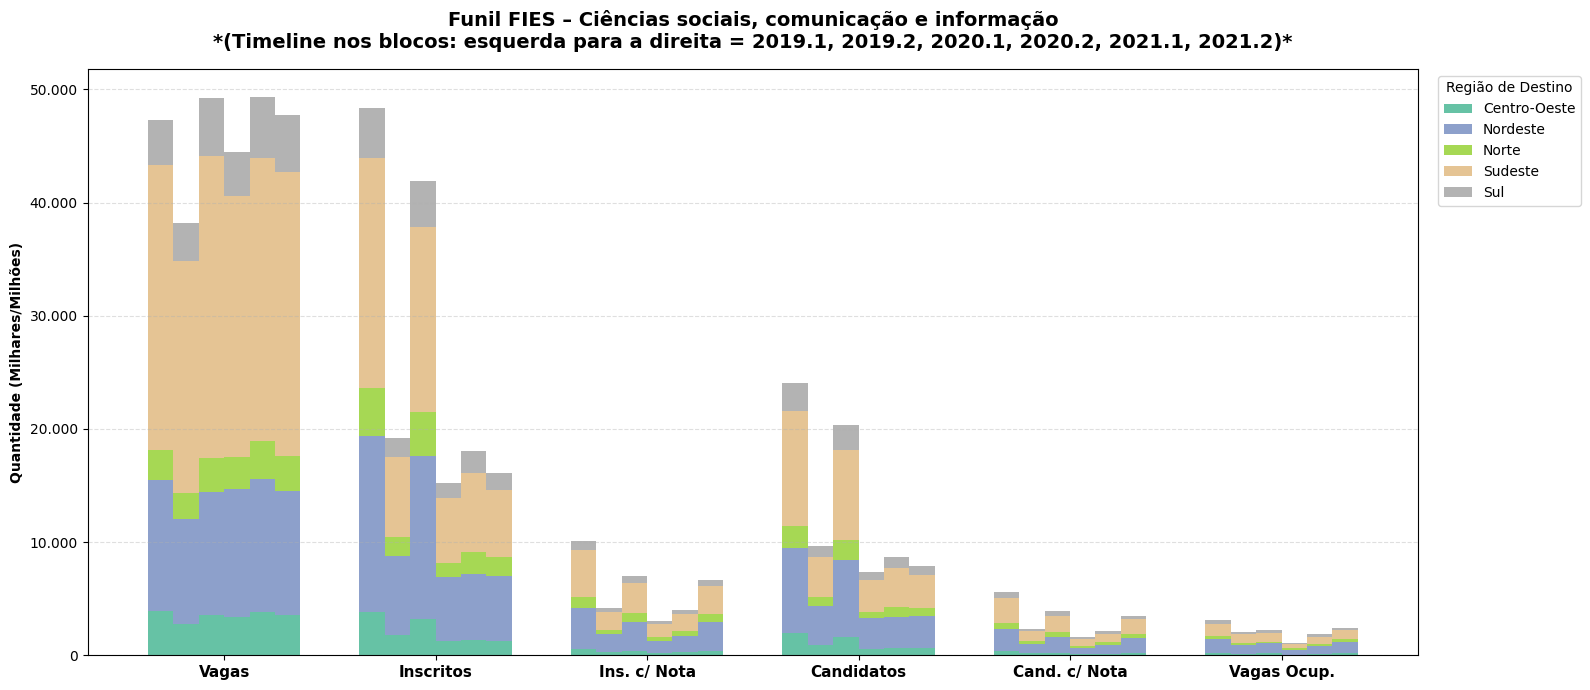

  -> Salvo: funil_computação_e_tecnologias_da_informação_e_comunicação_tic.png


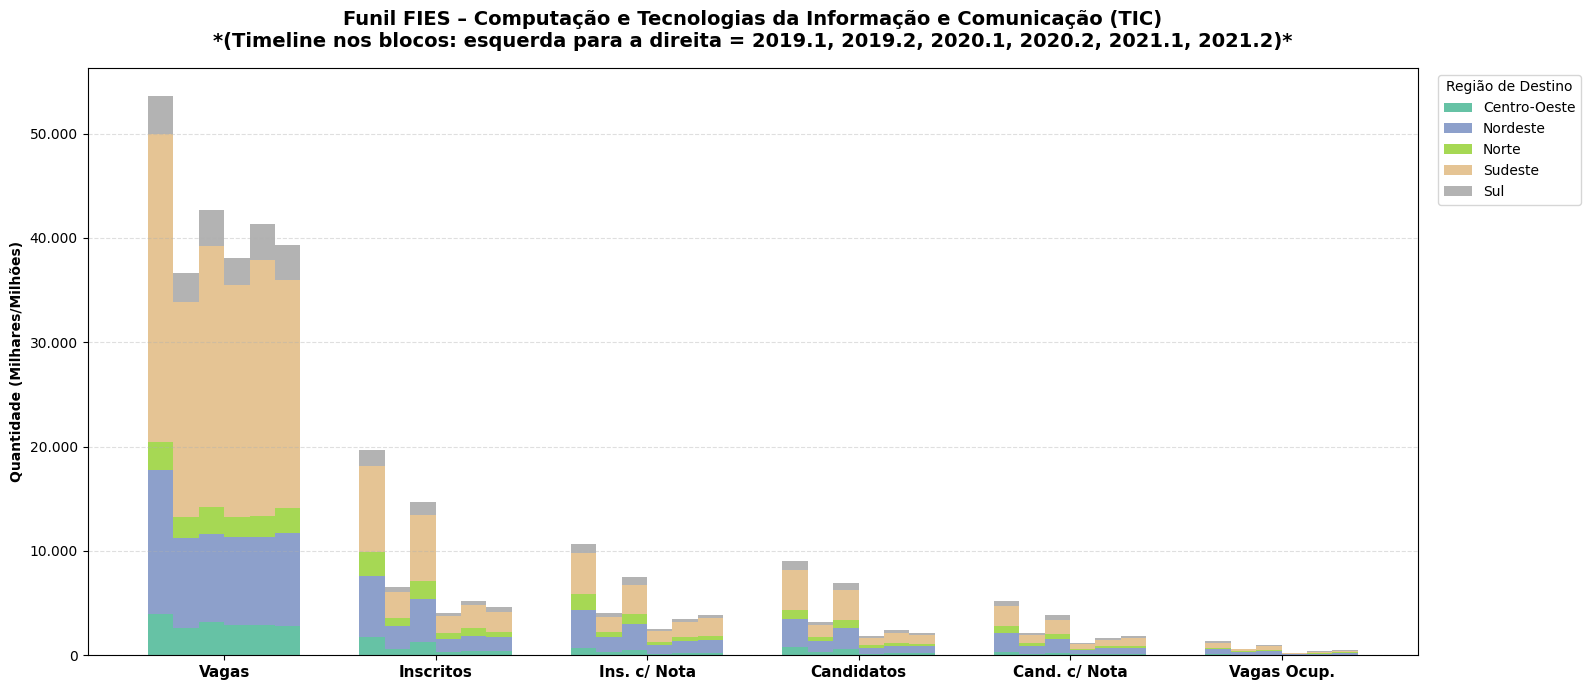

  -> Salvo: funil_educação.png


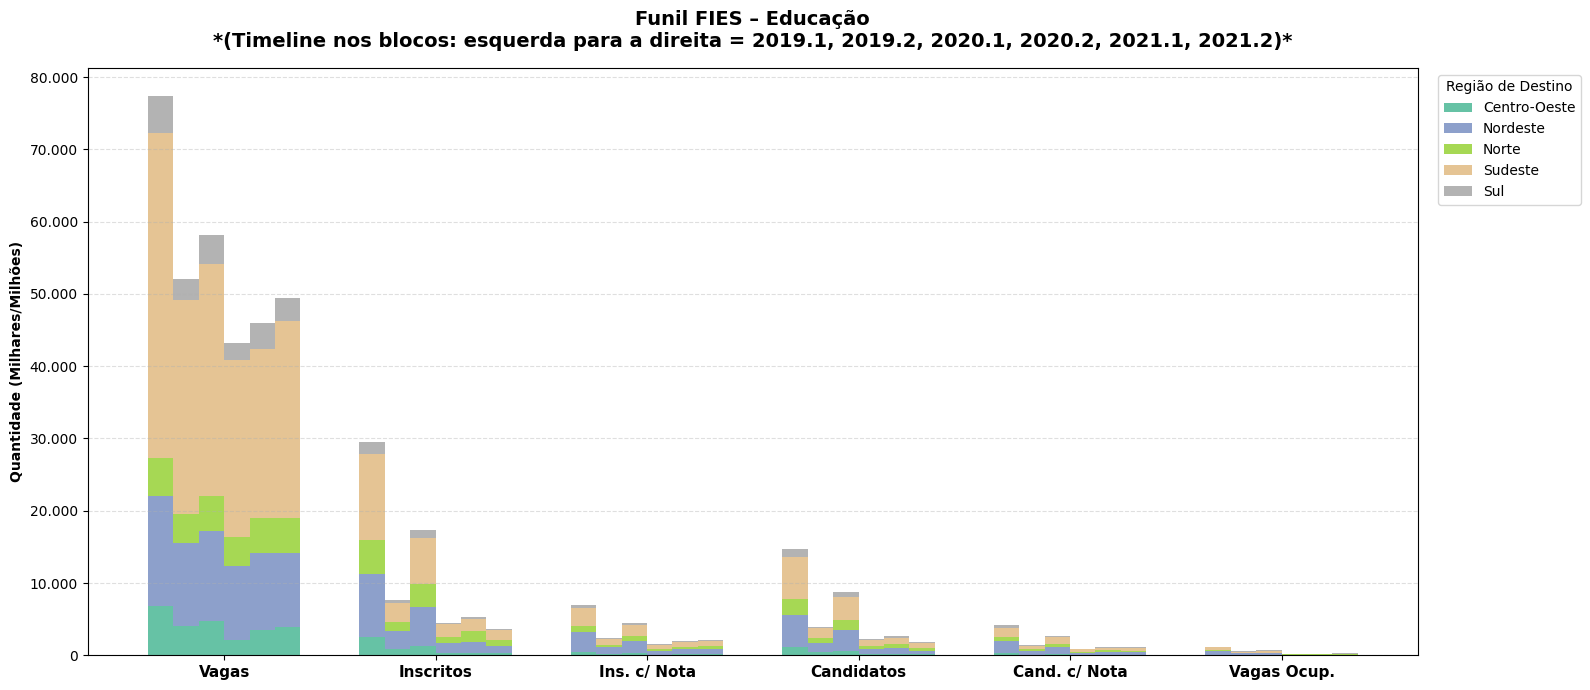

  -> Salvo: funil_engenharia_produção_e_construção.png


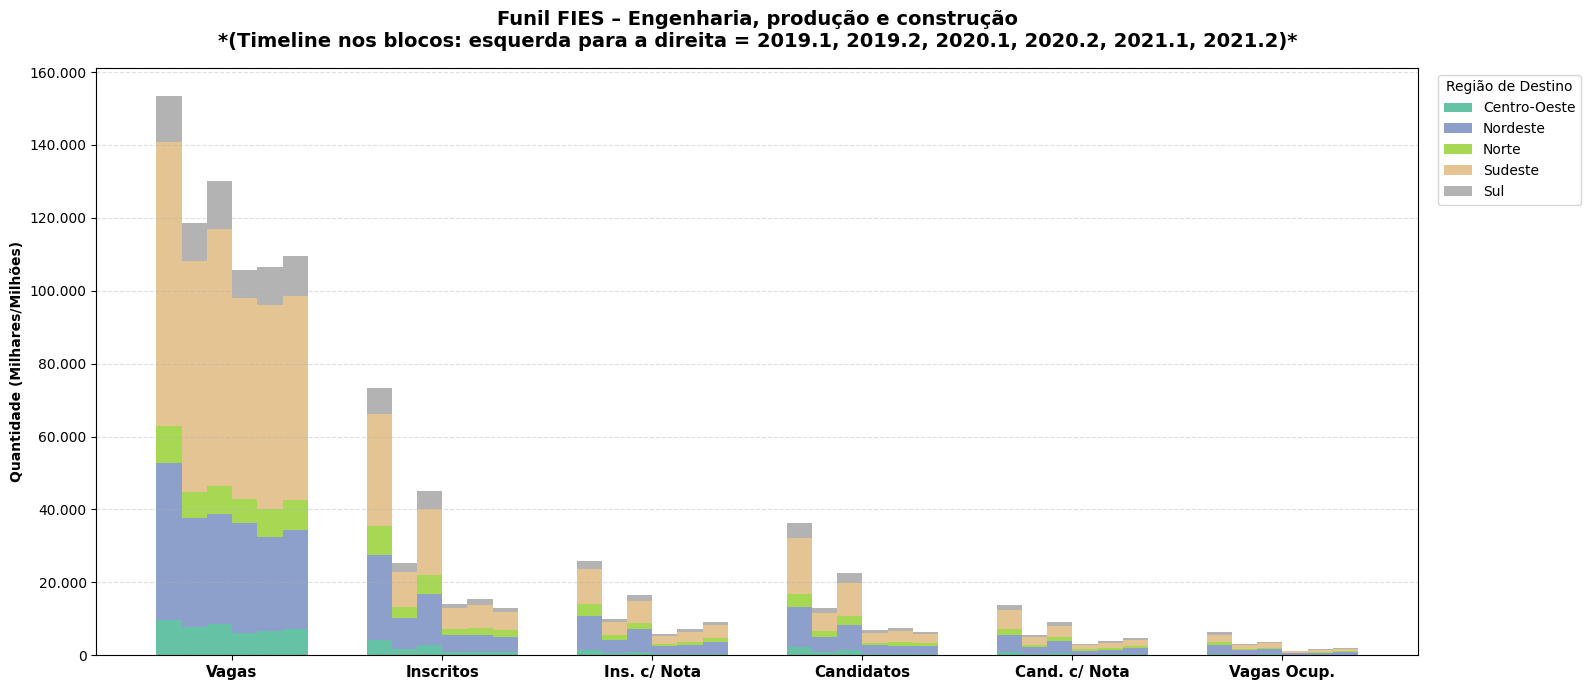

  -> Salvo: funil_negócios_administração_e_direito.png


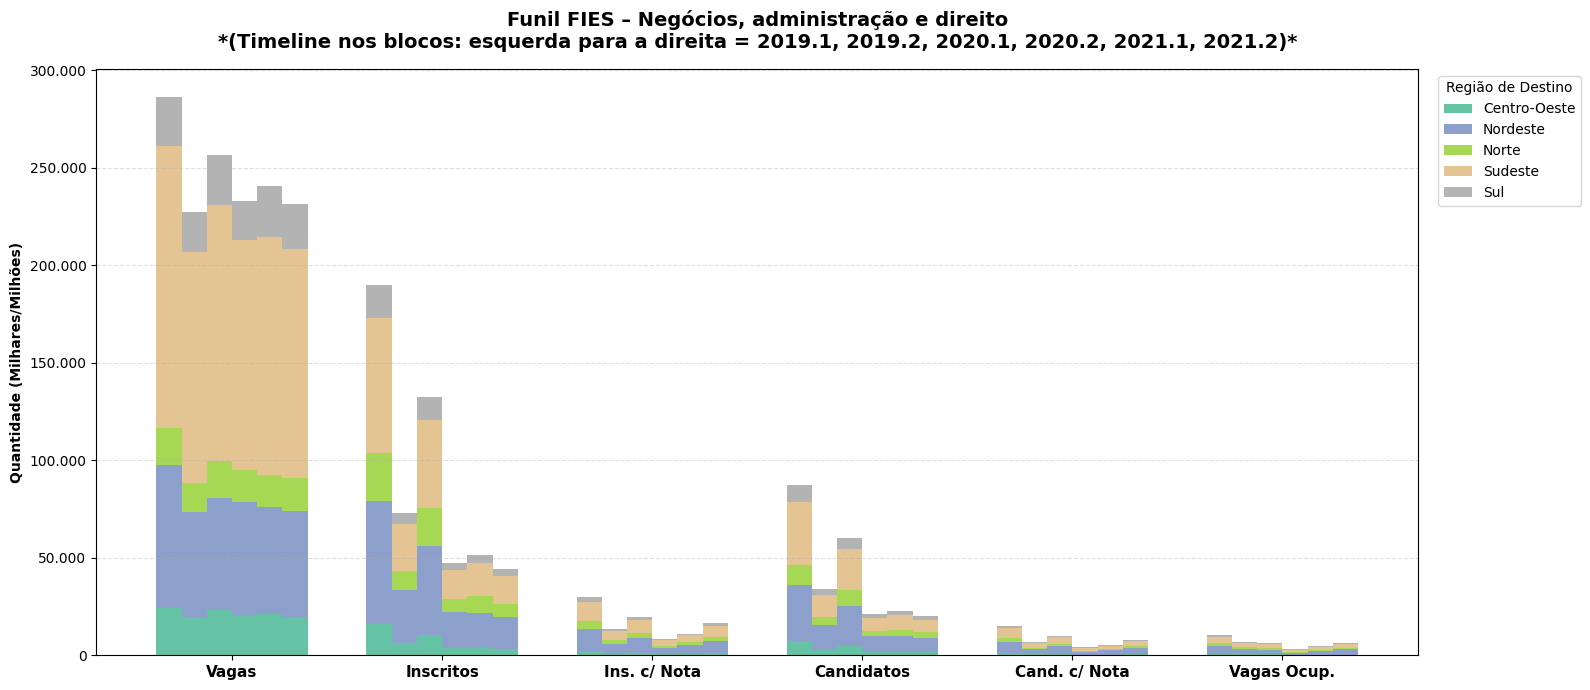

  -> Salvo: funil_saúde_e_bem_estar.png


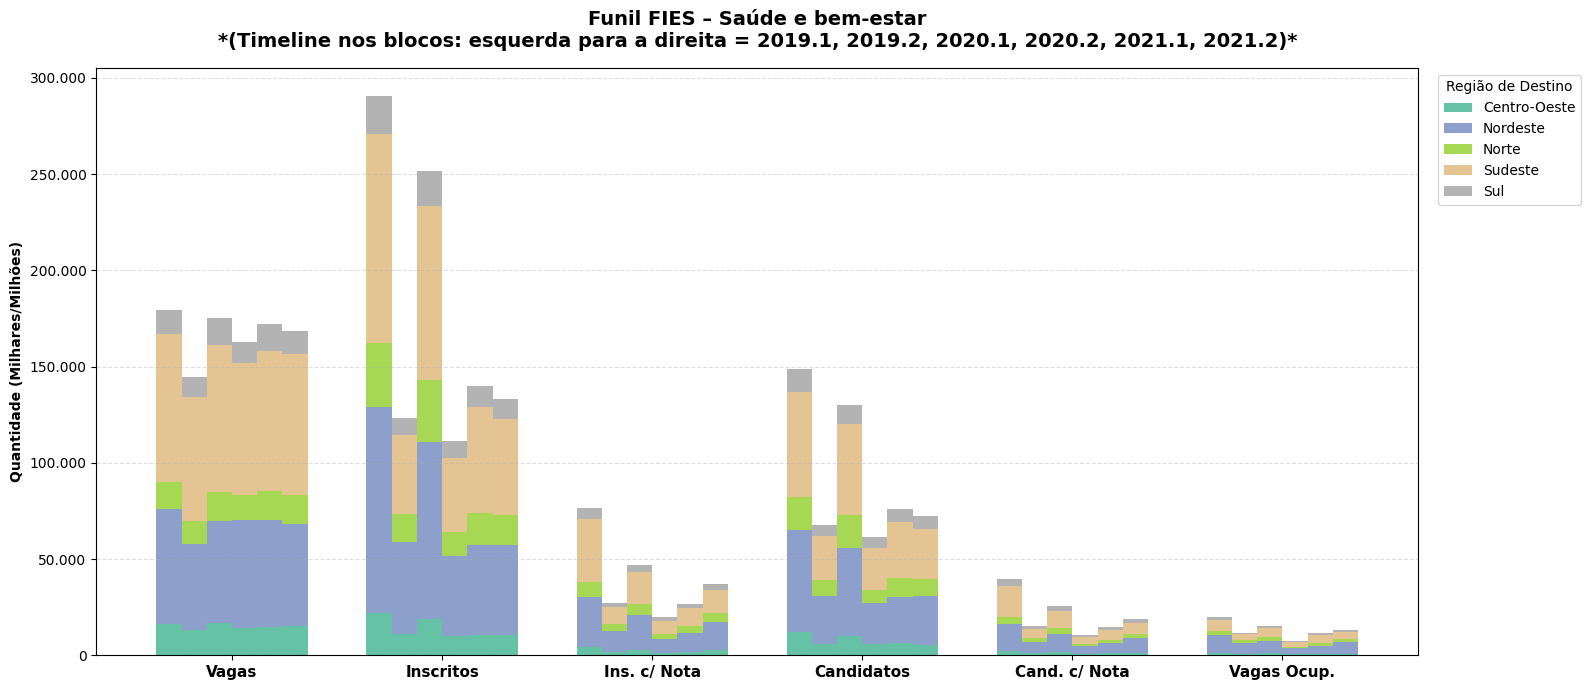

  -> Salvo: funil_serviços.png


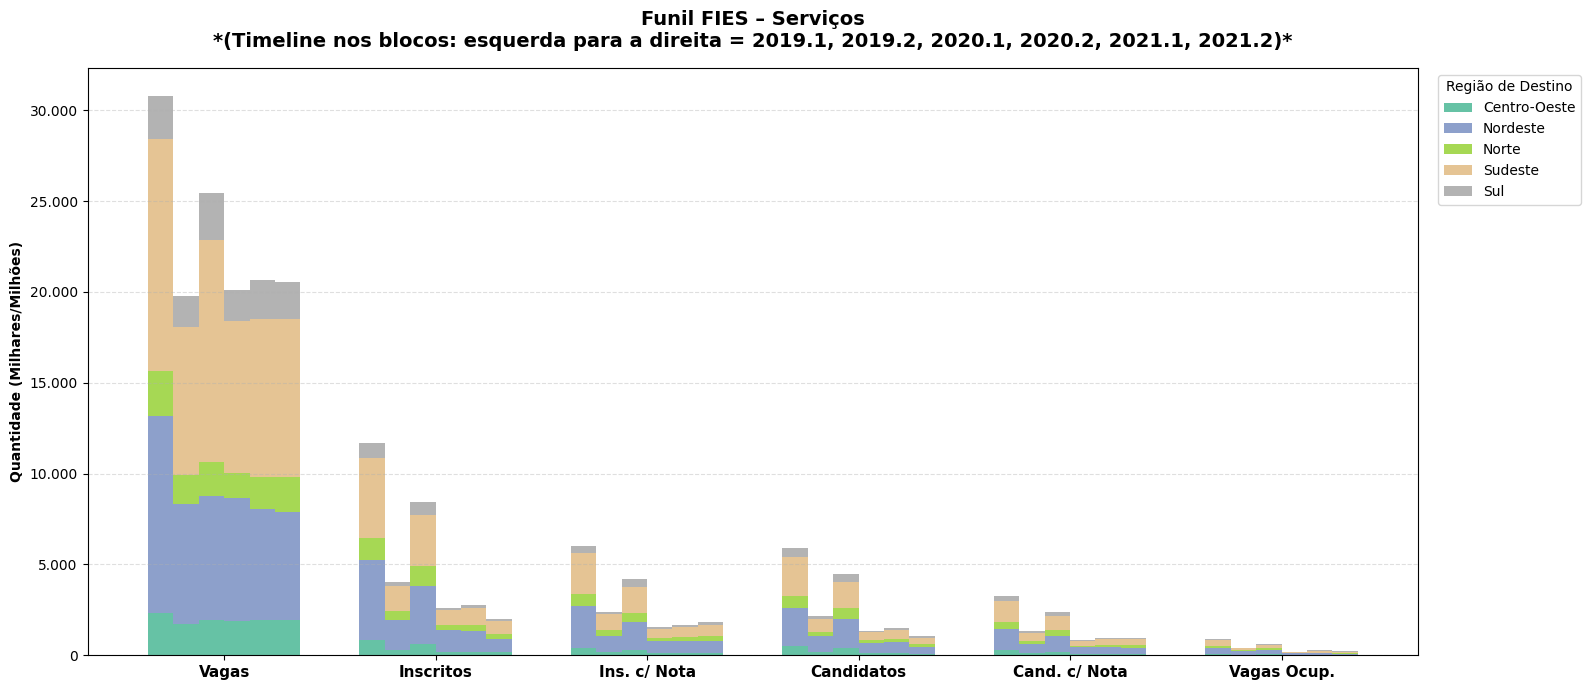


[*] Gerando e salvando gráfico Nacional...
  -> Salvo: funil_nacional_todas_areas.png


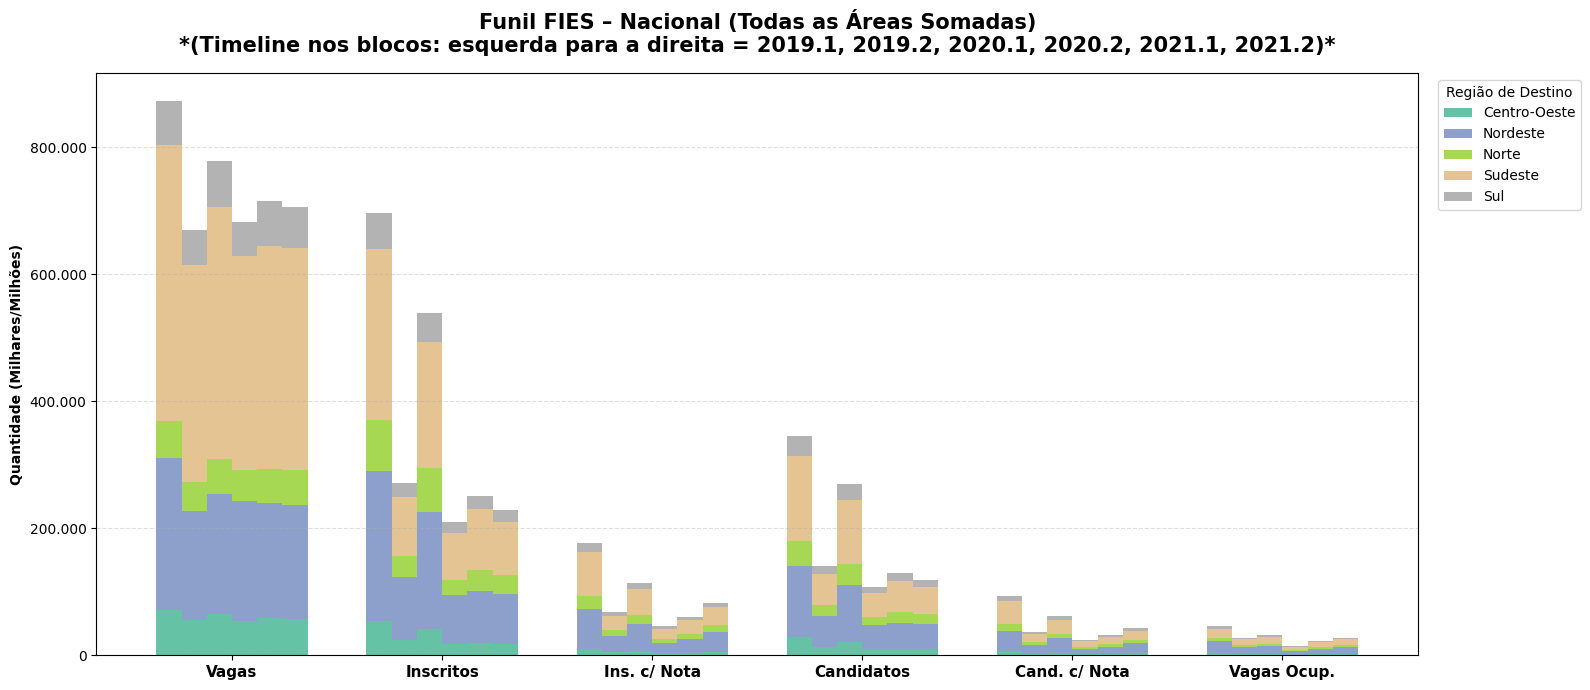


✅ Todos os gráficos foram salvos com sucesso!


In [ ]:
from constantes import pasta_data_05_processed
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import os
from pathlib import Path
import re

pd.set_option('display.max_columns', None)

# ==============================================================================
# 0. CONFIGURAÇÃO DE DIRETÓRIOS PARA SALVAR IMAGENS
# ==============================================================================
# Define a pasta destino relativa e resolve para o caminho absoluto
pasta_destino_graficos = Path('../reports/figures/analise_003').resolve()

# Cria a pasta e as subpastas (parents=True) caso não existam
pasta_destino_graficos.mkdir(parents=True, exist_ok=True)
print(f"[*] As imagens serão salvas em: {pasta_destino_graficos}")

# ==============================================================================
# 1. PREPARAÇÃO DOS DADOS
# ==============================================================================
path_funil_regiao = pasta_data_05_processed / 'funil_por_regiao.parquet'
df = pd.read_parquet(str(path_funil_regiao))

ajustar_nome_regiao = {'regiao_ies': 'regiao'}
df = df.rename(columns=ajustar_nome_regiao)

df['periodo'] = df['ano'].astype(str) + '.' + df['semestre'].astype(str)

colunas_funil = [
    'vagas_fies',
    'Inscritos_Geral',
    'inscritos_com_nota_suficiente',
    'Candidatos_Unicos_Geral',
    'candidatos_unicos_com_nota_suficiente',
    'vagas_ocupadas'
]

nomes_curto = {
    'vagas_fies': 'Vagas',
    'Inscritos_Geral': 'Inscritos',
    'inscritos_com_nota_suficiente': 'Ins. c/ Nota',
    'Candidatos_Unicos_Geral': 'Candidatos',
    'candidatos_unicos_com_nota_suficiente': 'Cand. c/ Nota',
    'vagas_ocupadas': 'Vagas Ocup.'
}

areas = sorted(df['nome_cine_area_geral'].unique())
periodos = sorted(df['periodo'].unique())
regioes = sorted(df['regiao'].unique())
largura_barra = 0.12
cores_regioes = plt.cm.Set2(np.linspace(0, 1, len(regioes)))

texto_timeline = f"*(Timeline nos blocos: esquerda para a direita = {', '.join(periodos)})*"

# Função para limpar strings virarem nomes de arquivos válidos
def limpar_nome_arquivo(nome):
    nome_limpo = re.sub(r'[^\w\s-]', '', nome) # Remove caracteres especiais
    return re.sub(r'[-\s]+', '_', nome_limpo).strip('_').lower()


# ==============================================================================
# 2. GERAÇÃO E EXPORTAÇÃO: GRÁFICOS POR ÁREA CINE
# ==============================================================================
print("\n[*] Gerando e salvando gráficos por Área CINE...")
for area in areas:
    df_area = df[df['nome_cine_area_geral'] == area]

    df_area_grouped = (
        df_area.groupby(['periodo', 'regiao'])[colunas_funil]
        .sum()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(16, 7))
    x = np.arange(len(colunas_funil))
    deslocamentos = np.linspace(-largura_barra * 2.5, largura_barra * 2.5, len(periodos))

    for desloc, periodo in zip(deslocamentos, periodos):
        df_periodo = df_area_grouped[df_area_grouped['periodo'] == periodo]
        base = np.zeros(len(colunas_funil))

        for cor, regiao in zip(cores_regioes, regioes):
            valores = df_periodo[df_periodo['regiao'] == regiao][colunas_funil]
            if valores.empty:
                valores = [0]*len(colunas_funil)
            else:
                valores = valores.values[0]

            ax.bar(x + desloc, valores, width=largura_barra, bottom=base, color=cor, label=regiao if periodo == periodos[0] else "")
            base += np.array(valores)

    ax.set_xticks(x)
    ax.set_xticklabels([nomes_curto[c] for c in colunas_funil], rotation=0, fontweight='bold', fontsize=11)
    ax.set_ylabel('Quantidade (Milhares/Milhões)', fontweight='bold')
    
    ax.set_title(f'Funil FIES – {area}\n{texto_timeline}', fontsize=14, fontweight='bold', pad=15)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'.replace(',', '.')))
    
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(title='Região de Destino', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1)

    plt.tight_layout()
    
    # SALVAR A IMAGEM ANTES DO SHOW
    nome_arquivo = f"funil_{limpar_nome_arquivo(area)}.png"
    caminho_salvar = pasta_destino_graficos / nome_arquivo
    plt.savefig(caminho_salvar, dpi=300, bbox_inches='tight')
    print(f"  -> Salvo: {nome_arquivo}")
    
    plt.show()

# ==============================================================================
# 3. GERAÇÃO E EXPORTAÇÃO: GRÁFICO NACIONAL (TODAS AS ÁREAS)
# ==============================================================================
print("\n[*] Gerando e salvando gráfico Nacional...")
df_total = df.groupby(['periodo', 'regiao'])[colunas_funil].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(colunas_funil))
deslocamentos = np.linspace(-largura_barra * 2.5, largura_barra * 2.5, len(periodos))
cores_regioes = plt.cm.Set2(np.linspace(0, 1, len(regioes)))

for desloc, periodo in zip(deslocamentos, periodos):
    df_periodo = df_total[df_total['periodo'] == periodo]
    base = np.zeros(len(colunas_funil))

    for cor, regiao in zip(cores_regioes, regioes):
        valores = df_periodo[df_periodo['regiao'] == regiao][colunas_funil]
        if valores.empty:
            valores = [0]*len(colunas_funil)
        else:
            valores = valores.values[0]

        ax.bar(x + desloc, valores, width=largura_barra, bottom=base, color=cor, label=regiao if periodo == periodos[0] else "")
        base += np.array(valores)

ax.set_xticks(x)
ax.set_xticklabels([nomes_curto[c] for c in colunas_funil], rotation=0, fontweight='bold', fontsize=11)
ax.set_ylabel('Quantidade (Milhares/Milhões)', fontweight='bold')

ax.set_title(f'Funil FIES – Nacional (Todas as Áreas Somadas)\n{texto_timeline}', fontsize=15, fontweight='bold', pad=15)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'.replace(',', '.')))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(title='Região de Destino', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()

# SALVAR A IMAGEM NACIONAL ANTES DO SHOW
nome_arquivo_nacional = "funil_nacional_todas_areas.png"
caminho_salvar_nacional = pasta_destino_graficos / nome_arquivo_nacional
plt.savefig(caminho_salvar_nacional, dpi=300, bbox_inches='tight')
print(f"  -> Salvo: {nome_arquivo_nacional}")

plt.show()

print("\n✅ Todos os gráficos foram salvos com sucesso!")